# Otimização de Algoritmos de CSP: Sudoku Solver
## De Backtracking com Strings para Vetorização com NumPy

Este notebook explora a resolução do Sudoku modelado como um **Problema de Satisfação de Restrições (CSP)**. O objetivo é demonstrar o impacto da escolha da estrutura de dados na performance computacional.

Serão comparadas duas implementações do mesmo algoritmo de *Constraint Propagation* (Propagação de Restrições) com *Backtracking*:

1.  **Python Puro (Abordagem Simbólica):** Utiliza manipulação de strings, sets e dicionários. Foca na legibilidade e na lógica de grafos.
2.  **NumPy (Abordagem Vetorial):** Utiliza tensores booleanos e operações matriciais. Foca em localidade de memória e operações em nível de C.

<br>

**Conceitos Chave:**
* **Constraint Propagation:** Eliminação de possibilidades com base nas regras do jogo (linhas, colunas, blocos).
* **Heurística MRV (Minimum Remaining Values):** Para o *backtracking*, sempre é escolhida a casa com o menor número de possibilidades restantes para minimizar a árvore de busca.

<br>

**Exemplo de tabuleiro com os respectivos índices:**

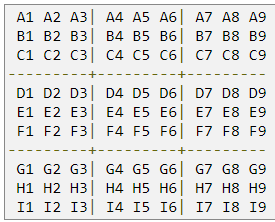

## Representação do Tabuleiro

Para representar o tabuleiro, são utilizadas duas formas:

  - *grid_str*: representação em string para o estado inicial do tabuleiro, em que as casas estão dispostas em sequência ("[A1][A2]...[A9][B1][B2]...[B9]...[I9]") com as casas vazias sendo representadas com um ponto e as preenchidas com os seus próprios valores;
  - *grid_dict*: representação em dicionário em que as chaves são as casas e os valores são pontos para casas vazias ou dígitos de 1 a 9 para casas preenchidas.

A seguir, há um tabuleiro e suas respectivas representações exemplificando o proposto acima.

In [13]:
# Constantes globais que definem a estrutura do tabuleiro
ROWS: str = 'ABCDEFGHI'
COLS: str = '123456789'



def cross(a: str, b: str) -> list[str]:
    """
    Gera o produto cartesiano (combinação de todos com todos) entre duas strings.

    Args:
        a (str): Primeira sequência de caracteres (ex: letras das linhas).
        b (str): Segunda sequência de caracteres (ex: números das colunas).

    Returns:
        List[str]: Uma lista contendo todas as concatenações possíveis (ex: ['A1', 'A2'...]).
    """
    return [s + t for s in a for t in b]



# Cria a lista de todas as coordenadas do tabuleiro (81 casas)
boxes: list[str] = cross(ROWS, COLS)

# Exemplo de visualização das primeiras e últimas coordenadas
print(f'[{boxes[0]}, {boxes[1]}, {boxes[2]}, ... , {boxes[-3]}, {boxes[-2]}, {boxes[-1]}]')

[A1, A2, A3, ... , I7, I8, I9]


In [14]:
# Criação dos dois tipos de grid
grid_str = "4.....8.5.3..........7......2.....6.....8.4......1.......6.3.7.5..2.....1.4......"
grid_dict = dict(zip(boxes, grid_str))



def display(grid_dict: dict[str, str]) -> None:
    """
    Exibe os valores do Sudoku formatados como uma grade 2D no console.

    A função ajusta automaticamente a largura das colunas com base no comprimento dos valores (útil para visualizar
    as possibilidades em cada casa).

    Args:
        grid_dict (Dict[str, str]): Dicionário representando o tabuleiro, onde:
            - Chave: Coordenada da casa (ex: 'A1').
            - Valor: Dígito preenchido ou string de possibilidades (ex: '5' ou '123').
    """
    # Calcula a largura da célula baseada no valor mais longo (para alinhamento)
    width = 1 + max(len(grid_dict[s]) for s in boxes)

    # Cria a linha horizontal separadora dos blocos 3x3
    line = '+'.join(['-' * (width * 3 + 1)] * 3)

    for r in ROWS:
        # Monta a string de cada linha do tabuleiro
        row_string = ''.join(
            grid_dict[r + c].center(width) + ('| ' if c in '36' else '')
            for c in COLS
        )
        print('', row_string)

        # Imprime a linha separadora após as linhas C e F (blocos verticais)
        if r in 'CF':
            print(line)



display(grid_dict)

 4 . . | . . . | 8 . 5 
 . 3 . | . . . | . . . 
 . . . | 7 . . | . . . 
-------+-------+-------
 . 2 . | . . . | . 6 . 
 . . . | . 8 . | 4 . . 
 . . . | . 1 . | . . . 
-------+-------+-------
 . . . | 6 . 3 | . 7 . 
 5 . . | 2 . . | . . . 
 1 . 4 | . . . | . . . 


## Abordagem Clássica: Estruturas de Dados Dinâmicas

Nesta implementação, o tabuleiro é tratado como um grafo.
* **Estado:** Um dicionário mapeando coordenadas (`'A1'`, `'C9'`) para strings de valores possíveis (ex: `'1245'`).
* **Regras:** Cada casa possui "pares" (peers) — todas as outras casas na mesma linha, coluna e bloco. Se uma casa é resolvida, seu valor é eliminado das possibilidades de seus pares.

Embora intuitiva, esta abordagem sofre com o *overhead* da criação de objetos (strings e listas) e loops nativos do Python.

In [15]:
import time



# Definição de Tipos
Grid = dict[str, str]
Result = Grid | bool



def combinacoes(a: str, b: str) -> list[str]:
    """
    Retorna o produto cartesiano (todas as combinações) entre duas strings.

    Args:
        a (str): Primeira sequência (ex: linhas).
        b (str): Segunda sequência (ex: colunas).

    Returns:
        list[str]: Lista de combinações (ex: ['A1', 'A2'...]).
    """
    return [s + t for s in a for t in b]



# Lista de todas as casas do tabuleiro (81 casas)
CASAS: list[str] = combinacoes(ROWS, COLS)

# Definição das Unidades (Linha, Coluna, Bloco)
unidades_linha = [combinacoes(l, COLS) for l in ROWS]
unidades_coluna = [combinacoes(ROWS, c) for c in COLS]
unidades_bloco = [combinacoes(l, c) for l in ('ABC', 'DEF', 'GHI') for c in ('123', '456', '789')]

LISTA_UNIDADES: list[list[str]] = unidades_linha + unidades_coluna + unidades_bloco

# Dicionário que mapeia cada casa para suas 3 unidades (linha, coluna, bloco)
UNITS: dict[str, list[list[str]]] = {}
for casa in CASAS:
    unidades_da_casa = [u for u in LISTA_UNIDADES if casa in u]
    UNITS[casa] = unidades_da_casa

# Dicionário que mapeia uma casa para seus "vizinhos" únicos (conjunto de restrição)
PEERS: dict[str, set[str]] = {}
for casa in CASAS:
    set_pares = set(sum(UNITS[casa], [])) - {casa}
    PEERS[casa] = set_pares



def obter_valores_grid(grid_string: str) -> Grid:
    """
    Converte a string inicial do tabuleiro em um dicionário de possibilidades.

    Args:
        grid_string (str): Representação linear do tabuleiro (ex: '4.....8.5...').

    Returns:
        Grid: Dicionário onde chaves são coordenadas ('A1') e valores são os dígitos fixos ou '123456789' para casas vazias.
    """

    caracteres = []
    digitos = '123456789'
    for char in grid_string:
        if char in digitos:
            caracteres.append(char)
        elif char == '.':
            # Casas vazias iniciam com todas as possibilidades
            caracteres.append(digitos)

    assert len(caracteres) == 81, "O grid deve ter exatamente 81 caracteres."
    return dict(zip(CASAS, caracteres))



def eliminar(valores: Grid, casa: str, digito: str) -> Result:
    """
    Elimina um dígito das possibilidades de uma casa e propaga restrições.

    Args:
        valores (Grid): Estado atual do tabuleiro.
        casa (str): Coordenada da casa (ex: 'A1').
        digito (str): Dígito a ser eliminado das possibilidades dessa casa.

    Returns:
        Result: O dicionário atualizado ou False se houver contradição.
    """

    # Se o dígito já não está nas possibilidades, nada a fazer
    if digito not in valores[casa]:
        return valores

    # Remove o dígito
    valores[casa] = valores[casa].replace(digito, '')

    # Se a casa ficou sem valores, houve erro/contradição
    if len(valores[casa]) == 0:
        return False

    # Se a casa tem apenas 1 valor restante, ele é a solução para ela
    elif len(valores[casa]) == 1:
        digito_restante = valores[casa]
        if not all(eliminar(valores, peer, digito_restante) for peer in PEERS[casa]):
            return False

    # Verifica as unidades (Linha, Coluna, Bloco) para ver se o dígito só pode estar em um lugar específico
    for unidade in UNITS[casa]:
        lugares_para_digito = [c for c in unidade if digito in valores[c]]

        if len(lugares_para_digito) == 0:
            return False # Contradição
        elif len(lugares_para_digito) == 1:
            if not atribuir(valores, lugares_para_digito[0], digito):
                return False

    return valores



def atribuir(valores: Grid, casa: str, digito_input: str) -> Result:
    """
    Atribui um valor a uma casa eliminando todas as outras possibilidades.

    Args:
        valores (Grid): Estado atual do tabuleiro.
        casa (str): Coordenada da casa.
        digito_input (str): Valor a ser fixado na casa.

    Returns:
        Result: O dicionário atualizado ou False se houver contradição.
    """

    outros_digitos = valores[casa].replace(digito_input, '')

    if all(eliminar(valores, casa, d) for d in outros_digitos):
        return valores
    else:
        return False



def buscar_solucao(valores: Result) -> Result:
    """
    Algoritmo de Busca (Backtracking) com heurística MRV.

    Args:
        valores (Result): Estado atual do tabuleiro ou False (falha anterior).

    Returns:
        Result: O tabuleiro resolvido ou False se não houver solução.
    """

    if valores is False:
        return False

    # Se todas as casas têm tamanho 1, está resolvido
    if all(len(valores[c]) == 1 for c in CASAS):
        return valores

    # Heurística MRV: Escolhe a casa com menor número de possibilidades (> 1)
    _, casa_escolhida = min((len(valores[c]), c) for c in CASAS if len(valores[c]) > 1)

    for digito in valores[casa_escolhida]:
        resultado = buscar_solucao(atribuir(valores.copy(), casa_escolhida, digito))

        if resultado:
            return resultado

    return False

In [47]:
def solucao(grid_string: str) -> Result:
    """
    Wrapper principal que recebe a string e retorna o dicionário resolvido.

    Args:
        grid_string (str): String representando o tabuleiro.

    Returns:
        Result: Dicionário representando o tabuleiro resolvido.
    """
    valores = obter_valores_grid(grid_string)
    return buscar_solucao(valores)



def validar_solucao(grid: dict[str, str]) -> bool:
    """
    Verifica se uma solução de Sudoku é válida (respeita todas as regras).

    Args:
        grid (dict[str, str]): O tabuleiro resolvido no formato de dicionário {'A1': '5', ...}.

    Returns:
        bool: True se a solução for válida, False caso contrário.
    """

    if not grid:
        return False


    # Conjunto esperado: todos os dígitos de 1 a 9
    expected = set(COLS)

    # Verificação das Linhas
    for r in ROWS:
        # Coleta os valores da linha atual (ex: A1, A2... A9)
        row_values = [grid[r + c] for c in COLS]
        if set(row_values) != expected:
            print(f"Erro na linha {r}: {row_values}")
            return False

    # Verificação das Colunas
    for c in COLS:
        # Coleta os valores da coluna atual (ex: A1, B1... I1)
        col_values = [grid[r + c] for r in ROWS]
        if set(col_values) != expected:
            print(f"Erro na coluna {c}: {col_values}")
            return False

    # Verificação dos Blocos 3x3
    # Itera sobre os grupos de linhas (ABC, DEF, GHI) e colunas (123, 456, 789)
    for r_block in ('ABC', 'DEF', 'GHI'):
        for c_block in ('123', '456', '789'):
            # Gera as coordenadas e coleta valores do bloco
            box_values = [grid[r + c] for r in r_block for c in c_block]
            if set(box_values) != expected:
                print(f"Erro no bloco {r_block}-{c_block}: {box_values}")
                return False

    return True



print("--- Tabuleiro Fácil ---")
grid_facil_str = '..3.2.6..9..3.5..1..18.64....81.29..7.......8..67.82....26.95..8..2.3..9..5.1.3..'
inicio = time.perf_counter()
tabuleiro_resolvido_facil = solucao(grid_facil_str)
fim = time.perf_counter()
display(tabuleiro_resolvido_facil)
print(f"Tempo de execução (Fácil): {fim - inicio:.6f} segundos")

valido = validar_solucao(tabuleiro_resolvido_facil)
if valido:
    print("\nSUCESSO: A solução gerada é matematicamente válida!")
else:
    print("\nERRO: A solução contém inconsistências.")


print("\n\n")


print("--- Tabuleiro Difícil ---")
grid_dificil_str = "4.....8.5.3..........7......2.....6.....8.4......1.......6.3.7.5..2.....1.4......"
inicio = time.perf_counter()
tabuleiro_resolvido_dificil = solucao(grid_dificil_str)
fim = time.perf_counter()
display(tabuleiro_resolvido_dificil)
tempo_dificil_classico = fim - inicio
print(f"Tempo de execução (Difícil): {fim - inicio:.6f} segundos")

valido = validar_solucao(tabuleiro_resolvido_dificil)
if valido:
    print("\nSUCESSO: A solução gerada é matematicamente válida!")
else:
    print("\nERRO: A solução contém inconsistências.")

--- Tabuleiro Fácil ---
 4 8 3 | 9 2 1 | 6 5 7 
 9 6 7 | 3 4 5 | 8 2 1 
 2 5 1 | 8 7 6 | 4 9 3 
-------+-------+-------
 5 4 8 | 1 3 2 | 9 7 6 
 7 2 9 | 5 6 4 | 1 3 8 
 1 3 6 | 7 9 8 | 2 4 5 
-------+-------+-------
 3 7 2 | 6 8 9 | 5 1 4 
 8 1 4 | 2 5 3 | 7 6 9 
 6 9 5 | 4 1 7 | 3 8 2 
Tempo de execução (Fácil): 0.014488 segundos

SUCESSO: A solução gerada é matematicamente válida!



--- Tabuleiro Difícil ---
 4 1 7 | 3 6 9 | 8 2 5 
 6 3 2 | 1 5 8 | 9 4 7 
 9 5 8 | 7 2 4 | 3 1 6 
-------+-------+-------
 8 2 5 | 4 3 7 | 1 6 9 
 7 9 1 | 5 8 6 | 4 3 2 
 3 4 6 | 9 1 2 | 7 5 8 
-------+-------+-------
 2 8 9 | 6 4 3 | 5 7 1 
 5 7 3 | 2 9 1 | 6 8 4 
 1 6 4 | 8 7 5 | 2 9 3 
Tempo de execução (Difícil): 163.852982 segundos

SUCESSO: A solução gerada é matematicamente válida!


## Otimização Vetorial com NumPy

A principal limitação da abordagem anterior é a manipulação excessiva de strings e iterações explícitas. Para otimizar, é realizada a mudança da representação dos dados para Álgebra Linear.

<br>

### Representação do Estado (Tensor 3D)
Em vez de strings, utiliza-se um cubo de dados (Tensor) de dimensões $(9, 9, 9)$:
* **Eixos 0 e 1 (9x9):** Representam as linhas e colunas do tabuleiro.
* **Eixo 2 (Profundidade 9):** Representa o **One-Hot Encoding** dos dígitos.

Se `grid[2, 3, 0] == 1`, significa que na linha 3, coluna 4, o número 1 é uma possibilidade válida.

<br>

### Ganhos de Performance
* **Operações Bitwise/Lógicas:** A eliminação de candidatos torna-se uma operação booleana em massa.
* **Vetorização:** Substituição de loops Python por operações otimizadas em C (ex: `np.sum`, `np.all`).
* **Localidade de Cache:** Arrays contíguos na memória são processados muito mais rápido pela CPU do que dicionários dispersos.

In [17]:
import numpy as np



# Gera a lista de coordenadas ('A1', 'A2'...)
casas: list[str] = [l + c for l in ROWS for c in COLS]


# Conversão rápida entre índices de matriz (0-8) e rótulos do tabuleiro ('A'-'I')
map_letra_para_num: dict[str, int] = {letra: i for i, letra in enumerate(ROWS)}
map_num_para_letra: dict[int, str] = {i: letra for i, letra in enumerate(ROWS)}



def coords_para_casa(coords: tuple[int, int]) -> str:
    """
    Converte coordenadas matriciais (row, col) para notação de xadrez do Sudoku.

    Args:
        coords (tuple[int, int]): Tupla (linha, coluna), ex: (0, 0).

    Returns:
        str: Identificador da casa, ex: 'A1'.
    """
    return map_num_para_letra[coords[0]] + str(coords[1] + 1)



# Dicionário que mapeia cada coordenada (r,c) para suas 3 unidades correspondentes
unidades_np: dict[tuple[int, int], list[list[tuple[int, int]]]] = {}
for r in range(9):
    for c in range(9):
        bloco_r, bloco_c = r // 3 * 3, c // 3 * 3
        unidades_np[(r, c)] = [
            [(r, j) for j in range(9)],  # Unidade da Linha
            [(i, c) for i in range(9)],  # Unidade da Coluna
            [(bloco_r + i, bloco_c + j) for i in range(3) for j in range(3)] # Unidade do Bloco
        ]


# Dicionário que mapeia uma coordenada com os "ataques" que seu preenchimento pode fazer
pares_np: dict[tuple[int, int], set[tuple[int, int]]] = {}
for r in range(9):
    for c in range(9):
        lista_unidades_da_coord = unidades_np[(r, c)]
        pares_set = set()
        for unidade in lista_unidades_da_coord:
            for coords in unidade:
                if coords != (r, c):
                    pares_set.add(coords)
        pares_np[(r, c)] = pares_set



def atribuir_np(possibilidades: np.ndarray, r: int, c: int, d: int) -> np.ndarray | bool:
    """
    Atribui um valor final a uma casa e propaga a restrição.

    Ao definir que a casa (r, c) contém o dígito 'd', esta função elimina todos os outros dígitos possíveis para esta mesma casa.

    Args:
        possibilidades (np.ndarray): Tensor 3D (9x9x9) do estado atual.
        r (int): Índice da linha (0-8).
        c (int): Índice da coluna (0-8).
        d (int): Índice do dígito (0-8, onde 0 representa o número 1).

    Returns:
        np.ndarray | bool: O tensor atualizado ou False em caso de contradição.
    """

    # Identifica todos os outros dígitos que ainda estão marcados como possíveis (1)
    outros_digitos = np.where(possibilidades[r, c, :])[0]

    for d2 in outros_digitos:
        if d2 != d:
            if eliminar_np(possibilidades, r, c, d2) is False:
                return False
    return possibilidades



def eliminar_np(possibilidades: np.ndarray, r: int, c: int, d: int) -> np.ndarray | bool:
    """
    Elimina um dígito candidato de uma casa e aplica propagação de restrições.

    Se a eliminação resultar em uma casa com apenas 1 candidato restante,
    esse candidato é confirmado e propagado para os vizinhos.
    Se resultar em 0 candidatos, retorna False (contradição).

    Args:
        possibilidades (np.ndarray): Tensor 3D (9x9x9) booleano/uint8.
        r (int): Índice da linha.
        c (int): Índice da coluna.
        d (int): Índice do dígito a eliminar.

    Returns:
        np.ndarray | bool: O tensor atualizado ou False.
    """

    # Se já foi eliminado (valor é 0), não faz nada
    if possibilidades[r, c, d] == 0:
        return possibilidades

    # Marca a possibilidade como Falsa (0)
    possibilidades[r, c, d] = 0

    # Conta quantas possibilidades restam na profundidade (eixo Z) dessa casa
    num_possibilidades = np.sum(possibilidades[r, c, :])

    # Caso 1: Contradição (Casa sem números possíveis)
    if num_possibilidades == 0:
        return False

    # Caso 2: Casa resolvida (Apenas 1 número possível)
    elif num_possibilidades == 1:
        digito_encontrado = np.where(possibilidades[r, c, :])[0][0]
        # Elimina esse dígito encontrado de todos os pares (vizinhos)
        for par_r, par_c in pares_np[(r, c)]:
            if eliminar_np(possibilidades, par_r, par_c, digito_encontrado) is False:
                return False


    # Verificação de Unidade (Unit Constraint):
    # Verifica se o dígito 'd' eliminado era o último local possível em alguma linha/coluna/bloco
    for unidade in unidades_np[(r, c)]:
        lugares_para_digito = []
        for ur, uc in unidade:
            # Verifica se o dígito 'd' ainda é possível nas outras casas da unidade
            if possibilidades[ur, uc, d] == 1:
                lugares_para_digito.append((ur, uc))

        if len(lugares_para_digito) == 0:
            return False # Contradição: não há lugar para o dígito nesta unidade
        elif len(lugares_para_digito) == 1:
            # O dígito 'd' só pode ficar em um lugar (ur, uc), então é atribuído lá
            ur, uc = lugares_para_digito[0]
            if atribuir_np(possibilidades, ur, uc, d) is False:
                return False

    return possibilidades



def buscar_solucao_np(possibilidades: np.ndarray | bool) -> np.ndarray | bool:
    """
    Executa a busca (Backtracking) utilizando heurísticas otimizadas com NumPy.

    Heurística MRV (Minimum Remaining Values):
    Utiliza operações vetoriais para encontrar rapidamente a casa não resolvida
    com a menor soma no eixo Z (menor quantidade de candidatos).

    Args:
        possibilidades (np.ndarray | bool): Estado atual ou False se falhou anteriormente.

    Returns:
        np.ndarray | bool: Matriz resolvida ou False.
    """

    if possibilidades is False:
        return False

    # Verifica se o tabuleiro está completo (todas as casas têm soma 1 no eixo Z)
    if np.all(np.sum(possibilidades, axis=2) == 1):
        return possibilidades

    # Calcula a soma ao longo do eixo 2 (profundidade) para saber quantos candidatos cada casa tem
    num_poss = np.sum(possibilidades, axis=2)

    # Define um valor alto (10) para casas já resolvidas (soma=1) para ignorá-las no argmin
    num_poss[num_poss == 1] = 10

    # Encontra os índices (r, c) da casa com o menor número de possibilidades
    idx_min = np.argmin(num_poss)
    r, c = np.unravel_index(idx_min, num_poss.shape)

    # Tenta cada dígito possível (onde o valor é 1/True)
    for d in np.where(possibilidades[r, c, :])[0]:
        # Copia a matriz para o próximo nível da recursão
        resultado = buscar_solucao_np(atribuir_np(possibilidades.copy(), r, c, d))

        if resultado is not False:
            return resultado

    return False

In [48]:
def solucao_np(grid_string: str) -> dict[str, str] | bool:
    """
    Função principal para resolver Sudoku usando NumPy.

    Inicializa um tensor 3D de possibilidades e aplica restrições iniciais.

    Args:
        grid_string (str): Tabuleiro em formato string ('4.....8...').

    Returns:
        dict[str, str] | bool: Dicionário resolvido ou False.
    """

    # Matriz 9x9x9 iniciada com 1 (todas as possibilidades abertas)
    possibilidades = np.ones((9, 9, 9), dtype=np.uint8)

    # Pré-processamento: Preenche os valores iniciais fixos
    for i, char in enumerate(grid_string):
        if '1' <= char <= '9':
            r, c = i // 9, i % 9
            d = int(char) - 1 # Converte '1'->0, '9'->8

            if atribuir_np(possibilidades, r, c, d) is False:
                return False

    solucao_matriz = buscar_solucao_np(possibilidades)

    if solucao_matriz is False:
        return False

    # Reconstrói o dicionário de saída a partir da matriz resolvida
    grid_final: dict[str, str] = {}
    for r in range(9):
        for c in range(9):
            # Pega o índice onde o valor é 1 (True)
            d = np.where(solucao_matriz[r, c, :])[0][0]
            grid_final[coords_para_casa((r, c))] = str(d + 1)

    return grid_final



print("--- Tabuleiro Fácil ---")
grid_facil_str = '..3.2.6..9..3.5..1..18.64....81.29..7.......8..67.82....26.95..8..2.3..9..5.1.3..'
inicio = time.perf_counter()
tabuleiro_resolvido_facil = solucao_np(grid_facil_str)
fim = time.perf_counter()
display(tabuleiro_resolvido_facil)
print(f"Tempo de execução (Fácil): {fim - inicio:.6f} segundos")

valido = validar_solucao(tabuleiro_resolvido_facil)
if valido:
    print("\nSUCESSO: A solução gerada é matematicamente válida!")
else:
    print("\nERRO: A solução contém inconsistências.")


print("\n\n")


print("--- Tabuleiro Difícil ---")
grid_dificil_str = "4.....8.5.3..........7......2.....6.....8.4......1.......6.3.7.5..2.....1.4......"
inicio = time.perf_counter()
tabuleiro_resolvido_dificil = solucao_np(grid_dificil_str)
fim = time.perf_counter()
display(tabuleiro_resolvido_dificil)
tempo_dificil_numpy = fim - inicio
print(f"Tempo de execução (Difícil): {fim - inicio:.6f} segundos")

valido = validar_solucao(tabuleiro_resolvido_dificil)
if valido:
    print("\nSUCESSO: A solução gerada é matematicamente válida!")
else:
    print("\nERRO: A solução contém inconsistências.")

--- Tabuleiro Fácil ---
 4 8 3 | 9 2 1 | 6 5 7 
 9 6 7 | 3 4 5 | 8 2 1 
 2 5 1 | 8 7 6 | 4 9 3 
-------+-------+-------
 5 4 8 | 1 3 2 | 9 7 6 
 7 2 9 | 5 6 4 | 1 3 8 
 1 3 6 | 7 9 8 | 2 4 5 
-------+-------+-------
 3 7 2 | 6 8 9 | 5 1 4 
 8 1 4 | 2 5 3 | 7 6 9 
 6 9 5 | 4 1 7 | 3 8 2 
Tempo de execução (Fácil): 0.010964 segundos

SUCESSO: A solução gerada é matematicamente válida!



--- Tabuleiro Difícil ---
 4 1 7 | 3 6 9 | 8 2 5 
 6 3 2 | 1 5 8 | 9 4 7 
 9 5 8 | 7 2 4 | 3 1 6 
-------+-------+-------
 8 2 5 | 4 3 7 | 1 6 9 
 7 9 1 | 5 8 6 | 4 3 2 
 3 4 6 | 9 1 2 | 7 5 8 
-------+-------+-------
 2 8 9 | 6 4 3 | 5 7 1 
 5 7 3 | 2 9 1 | 6 8 4 
 1 6 4 | 8 7 5 | 2 9 3 
Tempo de execução (Difícil): 0.023569 segundos

SUCESSO: A solução gerada é matematicamente válida!


## Análise Comparativa e Conclusão

Os testes de benchmark revelaram um contraste impressionante entre as duas abordagens. No cenário de tabuleiro "Difícil", que exige maior profundidade na árvore de busca (backtracking), a implementação vetorizada obteve um ganho de performance superior a **7.000x**.

<br>

### Por que essa diferença?

1.  **Overhead do Interpretador vs. Código Compilado:**
    * Na abordagem **Python Puro**, cada acesso a dicionário, criação de string e iteração de loop passa pelo interpretador Python, gerando um custo computacional acumulativo em milhões de chamadas recursivas.
    * Na abordagem **NumPy**, as operações pesadas ("eliminar candidatos", "verificar linhas") são delegadas para bibliotecas em **C** altamente otimizadas.

2.  **Acesso à Memória (Cache Locality):**
    * O dicionário Python espalha objetos na memória (ponteiros), causando frequentes **cache misses** na CPU.
    * O Tensor NumPy (`ndarray`) ocupa um bloco contíguo de memória. Isso permite que a CPU carregue linhas inteiras do tabuleiro para o cache L1/L2 de uma só vez, acelerando drasticamente a verificação de restrições.

**Veredito:** Embora a abordagem simbólica (Python puro) seja excelente para prototipagem e legibilidade, problemas de busca combinatória intensiva exigem estruturas de dados que maximizem a eficiência de hardware, como demonstrado pela solução matricial.

In [43]:
print(f"Tempo de execução com estruturas de dados dinâmicas: {tempo_dificil_classico:.6f} segundos")
print(f"Tempo de execução com estruturas de dados em NumPy: {tempo_dificil_numpy:.6f} segundos")
print("\n")
print(f"Ganho de velocidade: {tempo_dificil_classico / tempo_dificil_numpy:.2f}x")

Tempo de execução com estruturas de dados dinâmicas: 158.912380 segundos
Tempo de execução com estruturas de dados em NumPy: 0.020732 segundos


Ganho de velocidade: 7665.14x


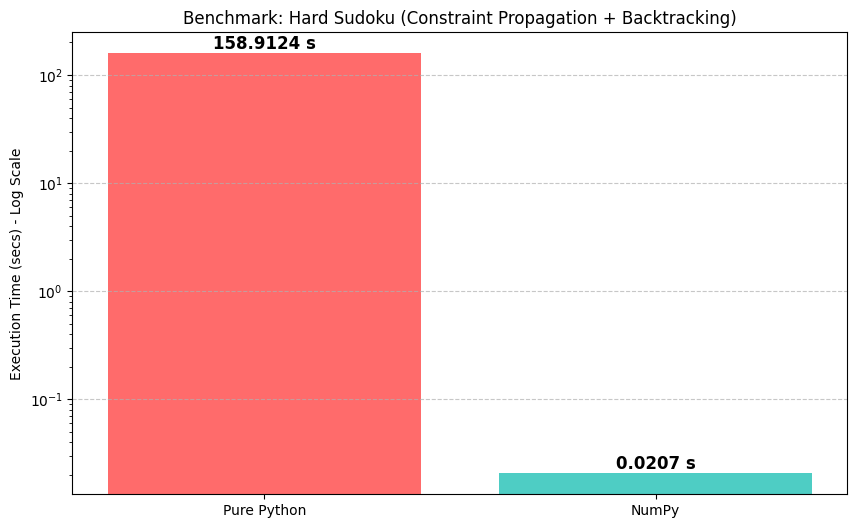

In [45]:
import matplotlib.pyplot as plt

# Dados para o gráfico
tempos = [tempo_dificil_classico, tempo_dificil_numpy]
labels = ['Pure Python', 'NumPy']
cores = ['#FF6B6B', '#4ECDC4']

plt.figure(figsize=(10, 6))
barras = plt.bar(labels, tempos, color=cores)

# Adiciona os valores acima das barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
             f'{altura:.4f} s',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.yscale('log') # Escala logarítmica é essencial aqui devido à diferença enorme
plt.ylabel('Execution Time (secs) - Log Scale')
plt.title('Benchmark: Hard Sudoku (Constraint Propagation + Backtracking)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()